In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
import seaborn as sns



In [2]:
df=pd.read_csv('spam_email_dataset.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   email_id                 10000 non-null  int64  
 1   subject                  10000 non-null  str    
 2   email_text               10000 non-null  str    
 3   num_words                10000 non-null  int64  
 4   num_characters           10000 non-null  int64  
 5   num_exclamation_marks    10000 non-null  int64  
 6   num_links                10000 non-null  int64  
 7   has_suspicious_link      10000 non-null  int64  
 8   num_attachments          10000 non-null  int64  
 9   has_attachment           10000 non-null  int64  
 10  sender_email             10000 non-null  str    
 11  sender_domain            10000 non-null  str    
 12  sender_reputation_score  10000 non-null  float64
 13  email_hour               10000 non-null  int64  
 14  email_day_of_week        10000 non

In [3]:
df.head()

,email_id,subject,email_text,num_words,num_characters,num_exclamation_marks,num_links,has_suspicious_link,num_attachments,has_attachment,sender_email,sender_domain,sender_reputation_score,email_hour,email_day_of_week,is_weekend,num_recipients,contains_money_terms,contains_urgency_terms,label
0,0,Weekly Report,budget review - Statement our I claim world st...,19,114,0,2,0,2,1,lctvdzm@outlook.com,outlook.com,0.66,19,3,0,23,0,0,0
1,1,Project Update,team sync - President series today already. In...,18,114,0,7,0,0,0,pxyldmi@company.com,company.com,0.95,4,4,0,16,1,0,0
2,2,🔥WIN BIG NOW!!,win free urgent offer limited limited urgent u...,19,126,0,4,1,1,1,atvanls@unknownmail.cc,unknownmail.cc,0.68,3,0,0,10,1,1,1
3,3,🔥WIN BIG NOW!!,guarantee click now cash offer click now guara...,16,101,0,7,1,1,1,qalxcnf@chealdealz.xyz,chealdealz.xyz,0.69,19,5,1,25,1,1,1
4,4,Meeting Reminder,team sync - Significant property hotel not add...,18,111,0,7,1,2,1,xoiccxl@yahoo.com,yahoo.com,0.67,4,5,1,8,0,0,0


In [4]:
x=df.drop(columns=['label'])
y=df['label']

In [5]:
df.head()

,email_id,subject,email_text,num_words,num_characters,num_exclamation_marks,num_links,has_suspicious_link,num_attachments,has_attachment,sender_email,sender_domain,sender_reputation_score,email_hour,email_day_of_week,is_weekend,num_recipients,contains_money_terms,contains_urgency_terms,label
0,0,Weekly Report,budget review - Statement our I claim world st...,19,114,0,2,0,2,1,lctvdzm@outlook.com,outlook.com,0.66,19,3,0,23,0,0,0
1,1,Project Update,team sync - President series today already. In...,18,114,0,7,0,0,0,pxyldmi@company.com,company.com,0.95,4,4,0,16,1,0,0
2,2,🔥WIN BIG NOW!!,win free urgent offer limited limited urgent u...,19,126,0,4,1,1,1,atvanls@unknownmail.cc,unknownmail.cc,0.68,3,0,0,10,1,1,1
3,3,🔥WIN BIG NOW!!,guarantee click now cash offer click now guara...,16,101,0,7,1,1,1,qalxcnf@chealdealz.xyz,chealdealz.xyz,0.69,19,5,1,25,1,1,1
4,4,Meeting Reminder,team sync - Significant property hotel not add...,18,111,0,7,1,2,1,xoiccxl@yahoo.com,yahoo.com,0.67,4,5,1,8,0,0,0


In [6]:
x

,email_id,subject,email_text,num_words,num_characters,num_exclamation_marks,num_links,has_suspicious_link,num_attachments,has_attachment,sender_email,sender_domain,sender_reputation_score,email_hour,email_day_of_week,is_weekend,num_recipients,contains_money_terms,contains_urgency_terms
0,0,Weekly Report,budget review - Statement our I claim world st...,19,114,0,2,0,2,1,lctvdzm@outlook.com,outlook.com,0.66,19,3,0,23,0,0
1,1,Project Update,team sync - President series today already. In...,18,114,0,7,0,0,0,pxyldmi@company.com,company.com,0.95,4,4,0,16,1,0
2,2,🔥WIN BIG NOW!!,win free urgent offer limited limited urgent u...,19,126,0,4,1,1,1,atvanls@unknownmail.cc,unknownmail.cc,0.68,3,0,0,10,1,1
3,3,🔥WIN BIG NOW!!,guarantee click now cash offer click now guara...,16,101,0,7,1,1,1,qalxcnf@chealdealz.xyz,chealdealz.xyz,0.69,19,5,1,25,1,1
4,4,Meeting Reminder,team sync - Significant property hotel not add...,18,111,0,7,1,2,1,xoiccxl@yahoo.com,yahoo.com,0.67,4,5,1,8,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,🔥WIN BIG NOW!!,free win cash win guarantee urgent free win li...,22,136,0,5,1,0,0,fefsrcz@unknownmail.cc,unknownmail.cc,0.68,8,1,0,29,1,1
9996,9996,You are selected!!!,click now free guarantee free win click now wi...,26,158,0,2,0,0,0,yxyctux@chealdealz.xyz,chealdealz.xyz,0.76,2,3,0,29,0,1
9997,9997,You are selected!!!,offer cash win limited click now cash limited ...,21,124,0,3,1,1,1,tkvqnki@unknownmail.cc,unknownmail.cc,0.69,6,1,0,25,0,1
9998,9998,Meeting Reminder,budget review - Many result affect idea.,7,40,0,1,0,2,1,wmvnrbn@outlook.com,outlook.com,0.80,7,2,0,18,0,0


In [7]:
y


0       0
1       0
2       1
3       1
4       0
       ..
9995    1
9996    1
9997    1
9998    0
9999    0
Name: label, Length: 10000, dtype: int64

In [8]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,train_size=0.8,random_state=42)

In [9]:
cat_cols = x.select_dtypes(include='object').columns
df[cat_cols].nunique()

C:\Users\ANUSHKA SAHA\AppData\Local\Temp\ipykernel_15876\117735172.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = x.select_dtypes(include='object').columns


subject              8
email_text       10000
sender_email     10000
sender_domain        8
dtype: int64

In [10]:
num_cols= x.select_dtypes(include='number').columns
df[num_cols].nunique()

email_id                   10000
num_words                     29
num_characters               189
num_exclamation_marks          1
num_links                      9
has_suspicious_link            2
num_attachments                3
has_attachment                 2
sender_reputation_score       71
email_hour                    24
email_day_of_week              7
is_weekend                     2
num_recipients                30
contains_money_terms           2
contains_urgency_terms         2
dtype: int64

<Axes: >

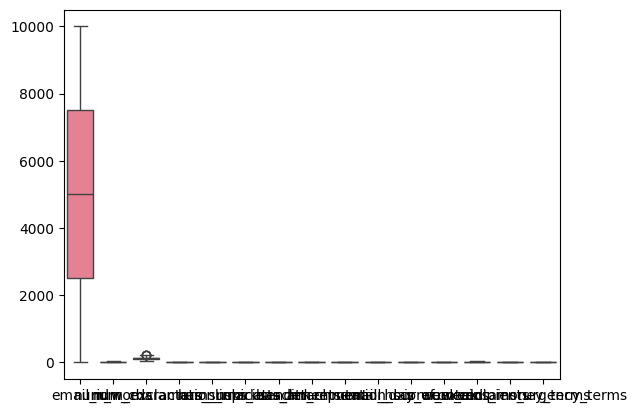

In [11]:
sns.boxplot(df[num_cols])

In [12]:
preprocessing = ColumnTransformer(
    transformers=[
        ('encode',OneHotEncoder(handle_unknown='ignore',sparse_output=False),cat_cols)
    ],remainder='passthrough'
)
# preprocessing.fit_transform(xtrain)
# preprocessing.get_feature_names_out()
main_pipline = Pipeline(
    steps=[
        ('pre',preprocessing),
        ('model',DecisionTreeClassifier(
            random_state=42,
            criterion='entropy',
            max_depth=4))
    ]
)
main_pipline.fit(xtrain,ytrain)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['email_id','subject','email_text',...,'num_recipients', 'contains_money_terms','contains_urgency_terms']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('encode', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passth

In [13]:
# Train Data

ytrain_pred = main_pipline.predict(xtrain)
print(classification_report(ytrain,ytrain_pred))

              precision    recall  f1-score   support

           0       0.96      0.87      0.91      4824
           1       0.82      0.94      0.88      3176

    accuracy                           0.89      8000
   macro avg       0.89      0.90      0.89      8000
weighted avg       0.90      0.89      0.90      8000



In [14]:
# test data
ytest_pred = main_pipline.predict(xtest)
print(classification_report(ytest,ytest_pred))

              precision    recall  f1-score   support

           0       0.94      0.85      0.90      1181
           1       0.81      0.93      0.87       819

    accuracy                           0.88      2000
   macro avg       0.88      0.89      0.88      2000
weighted avg       0.89      0.88      0.88      2000

